In [1]:
import os
from Bio import SeqIO
from collections import Counter
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

def run_naive_bayes(repeats_folder, train_folder, test_folder, output_file, top_features=10):
    # -----------------------------
    # 1️⃣ Load known repeats
    repeats = []
    for file in os.listdir(repeats_folder):
        if file.startswith("."):
            continue
        with open(os.path.join(repeats_folder, file), "r") as f:
            for line in f:
                parts = line.strip().split(",")
                if len(parts) >= 2:
                    repeats.append(parts[1])
    known_repeats = list(set(r for r in repeats if "X" not in r))
    known_repeats = list(set(r for r in known_repeats if "N" not in r))
    print(f"Number of unique repeats: {len(known_repeats)}")

    # -----------------------------
    # 2️⃣ Load training data
    sequencesTrain, labelTrain = [], []
    for file in os.listdir(train_folder):
        if file.startswith("."):
            continue
        filepath = os.path.join(train_folder, file)
        for record in SeqIO.parse(filepath, "fasta"):
            sequencesTrain.append(str(record.seq))
            labelTrain.append(file.replace(".fasta", ""))

    # -----------------------------
    # 3️⃣ Load test data
    sequencesTest, labelTest = [], []
    for file in os.listdir(test_folder):
        if file.startswith("."):
            continue
        filepath = os.path.join(test_folder, file)
        for record in SeqIO.parse(filepath, "fasta"):
            sequencesTest.append(str(record.seq))
            labelTest.append(file.replace(".fasta", ""))

    # -----------------------------
    # 4️⃣ Feature extraction
    def extract_repeat_counts(sequence, repeat_list):
        return [sequence.count(r) for r in repeat_list]

    X_train = [extract_repeat_counts(seq, known_repeats) for seq in sequencesTrain]
    X_test = [extract_repeat_counts(seq, known_repeats) for seq in sequencesTest]

    # -----------------------------
    # 5️⃣ Encode labels
    encoder = LabelEncoder()
    y_train_enc = encoder.fit_transform(labelTrain)
    y_test_enc = encoder.transform(labelTest)

    # -----------------------------
    # 6️⃣ Train Naive Bayes
    nb = MultinomialNB()
    nb.fit(X_train, y_train_enc)

    # -----------------------------
    # 7️⃣ Predict & Evaluate
    y_pred_enc = nb.predict(X_test)
    y_pred = encoder.inverse_transform(y_pred_enc)
    y_true = encoder.inverse_transform(y_test_enc)

    y_pred_enc_train = nb.predict(X_train)
    y_pred_train = encoder.inverse_transform(y_pred_enc_train)
    y_true_train = encoder.inverse_transform(y_train_enc)

    report = classification_report(y_true, y_pred)
    acc_test = accuracy_score(y_true, y_pred)
    acc_train = accuracy_score(y_true_train, y_pred_train)

    print("Classification report: ")
    print(report)
    print("Accuracy score test: " + str(acc_test))
    print("Accuracy score train: " + str(acc_train))

    with open(output_file, "w") as f:
        f.write(report)
        f.write("\nAccuracy score test: " + str(acc_test))
        f.write("\nAccuracy score train: " + str(acc_train))

    # -----------------------------
    # 8️⃣ Global Feature Importance via Mutual Information
    mi = mutual_info_classif(X_train, y_train_enc, discrete_features=True)
    top_indices = np.argsort(mi)[::-1][:top_features]

    # -----------------------------
    # 9️⃣ Plot feature importance
    plt.figure(figsize=(10, 6))
    plt.bar(range(top_features), mi[top_indices], align="center")
    plt.xticks(range(top_features), [known_repeats[i] for i in top_indices], rotation=90)
    plt.title(f"Top {top_features} Important Repeats (Mutual Information)")
    plt.ylabel("Mutual Information Score")
    plt.tight_layout()
    plt.show()

    return nb, encoder, known_repeats

Number of unique repeats: 990
Classification report: 
              precision    recall  f1-score   support

   HCoV-229E       1.00      1.00      1.00       153
   HCoV-HKU1       1.00      1.00      1.00       100
   HCoV-NL63       1.00      1.00      1.00       213
   HCoV-OC43       1.00      0.98      0.99       366
         IBV       1.00      0.99      1.00      3149
    MERS-CoV       1.00      1.00      1.00       395
    SARS-CoV       0.00      0.00      0.00         3
   SARS-CoV2       1.00      1.00      1.00      2133
     bat-CoV       0.83      1.00      0.91        15
  bovine-CoV       0.98      1.00      0.99       375
  canine-CoV       0.88      0.91      0.90       217
 dolphin-CoV       0.43      1.00      0.60         3
  equine-CoV       0.78      0.88      0.82         8
  feline-CoV       0.97      0.96      0.96       536
  ferret-CoV       0.60      0.46      0.52        13
hedgehog-CoV       0.67      1.00      0.80         6
 porcine-CoV       0.99    

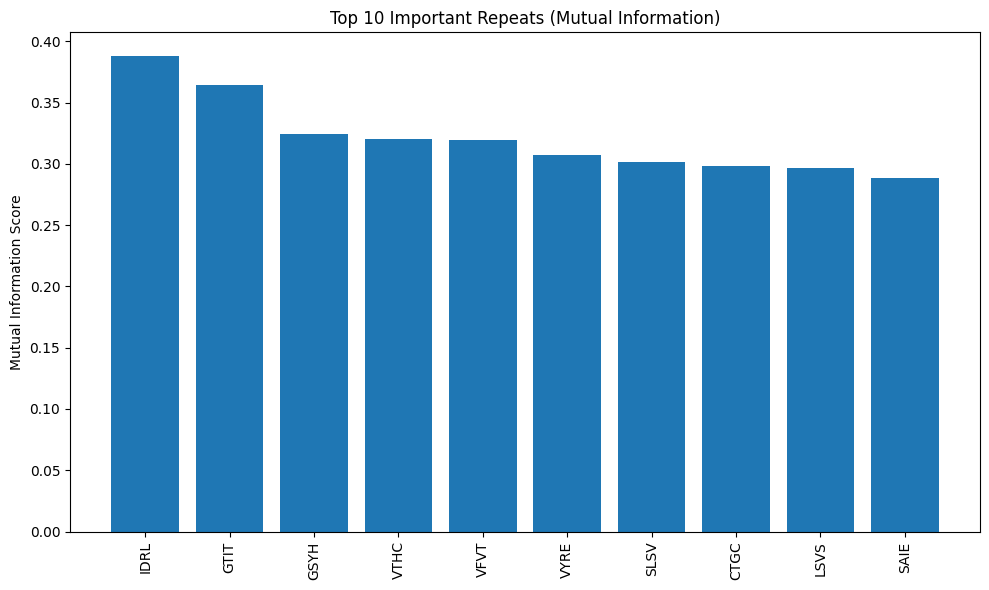

(MultinomialNB(),
 LabelEncoder(),
 ['GIGV',
  'RSRRS',
  'LPTS',
  'SEIY',
  'LVIG',
  'SISL',
  'ESYE',
  'YSIY',
  'DGLR',
  'LDSK',
  'VGVI',
  'IRVS',
  'IGVI',
  'VTYT',
  'VGTY',
  'DSDS',
  'AVDC',
  'CVRS',
  'VYRR',
  'VPSW',
  'STKP',
  'FGSL',
  'TGRL',
  'LTQH',
  'CSFG',
  'SLLM',
  'LEAQ',
  'LSVS',
  'YAYV',
  'TAYE',
  'GFIT',
  'TPEL',
  'PTVT',
  'FGIT',
  'TAEV',
  'TIIG',
  'ITDAV',
  'LLGS',
  'SGYT',
  'ISTY',
  'SHSV',
  'ELYE',
  'VDGG',
  'LASS',
  'YTSS',
  'SSFG',
  'PFSVI',
  'FVED',
  'VTAS',
  'PVAS',
  'LRCR',
  'SVLS',
  'ILDQ',
  'SQTS',
  'TVDD',
  'PDGF',
  'GSGY',
  'FGGI',
  'LLAF',
  'GSLF',
  'IDRL',
  'RRRS',
  'VDGV',
  'AIVT',
  'SQQL',
  'RRRR',
  'SAIE',
  'SAIL',
  'VTKV',
  'LQSG',
  'VETF',
  'GSYH',
  'GGVI',
  'IDTF',
  'IKVL',
  'AGAA',
  'SAIVT',
  'ELEE',
  'QDVI',
  'VYDG',
  'SAEL',
  'CVTT',
  'LQQV',
  'SGII',
  'RSTS',
  'SISD',
  'ETYV',
  'FKTG',
  'VTPL',
  'ECGL',
  'FDFK',
  'GVTM',
  'QYRP',
  'TALS',
  'TKLLS',
  'LGGY',


In [5]:
run_naive_bayes("../proba2/direct", 
                "../trainSet", 
                "../testSet", 
                "classification_report_NB_direct_2", top_features=10)

Number of unique repeats: 1495
Classification report: 
              precision    recall  f1-score   support

   HCoV-229E       1.00      1.00      1.00       153
   HCoV-HKU1       1.00      1.00      1.00       100
   HCoV-NL63       1.00      1.00      1.00       213
   HCoV-OC43       0.99      0.99      0.99       366
         IBV       0.97      1.00      0.98      3149
    MERS-CoV       1.00      0.99      1.00       395
    SARS-CoV       0.00      0.00      0.00         3
   SARS-CoV2       1.00      0.99      1.00      2133
     bat-CoV       0.83      1.00      0.91        15
  bovine-CoV       0.98      1.00      0.99       375
  canine-CoV       0.95      0.90      0.92       217
 dolphin-CoV       1.00      1.00      1.00         3
  equine-CoV       1.00      0.88      0.93         8
  feline-CoV       0.97      0.83      0.89       536
  ferret-CoV       1.00      0.38      0.56        13
hedgehog-CoV       0.83      0.83      0.83         6
 porcine-CoV       1.00   

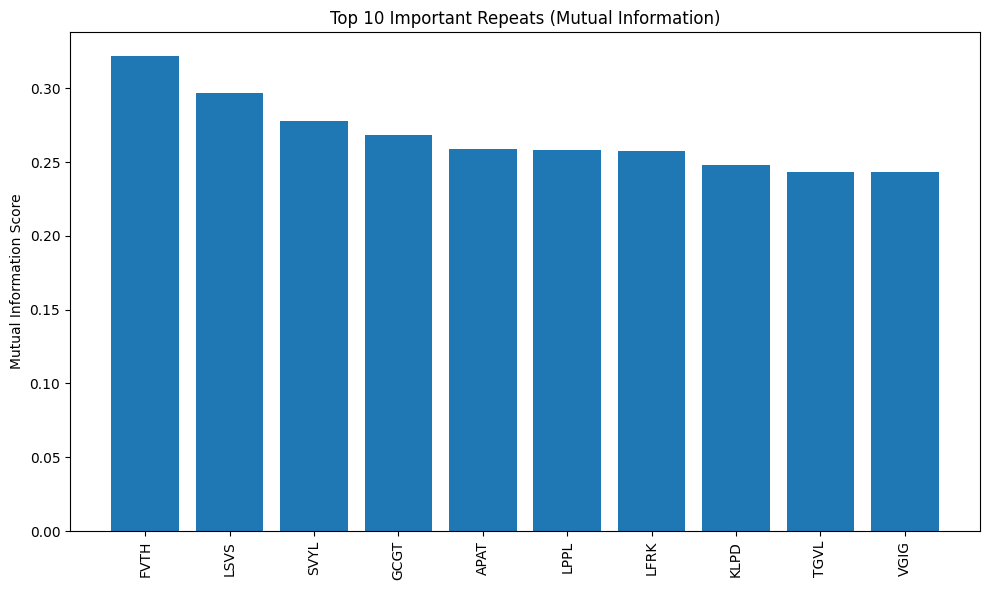

(MultinomialNB(),
 LabelEncoder(),
 ['LLTLL',
  'ARRA',
  'LLTR',
  'LLPP',
  'VGVI',
  'VYSYV',
  'TVTVT',
  'SILIS',
  'VPRPV',
  'VAST',
  'LLSLL',
  'LSVS',
  'LFSF',
  'SRMGMRS',
  'LVDT',
  'FVHR',
  'SGKGS',
  'VLDRV',
  'VGSGSGV',
  'TLVGVLT',
  'YVDVY',
  'RVGVR',
  'VDFDV',
  'KFGL',
  'IYYI',
  'IKVL',
  'VPVI',
  'DEIV',
  'ADDA',
  'GSSD',
  'TSTST',
  'ELPLE',
  'VLGLV',
  'YTPTY',
  'QRALL',
  'TATAT',
  'KSQSK',
  'DIPF',
  'GKIV',
  'ADPS',
  'FAIAF',
  'YSTSY',
  'SGDA',
  'AMQMA',
  'DSVSD',
  'TAAAT',
  'YVVY',
  'SRRARRS',
  'LLTL',
  'VLLLLV',
  'DSSSD',
  'VEGF',
  'RGSF',
  'CCGCC',
  'SSYSS',
  'SFVT',
  'TQSL',
  'SGIC',
  'FGSSGF',
  'SDLI',
  'TTTG',
  'DLQLD',
  'YQQY',
  'ILVF',
  'GLLS',
  'QLEQ',
  'EDDE',
  'EYYE',
  'LALAL',
  'SVVE',
  'VLILV',
  'PSIS',
  'ELELE',
  'VKDF',
  'VVDG',
  'SFSF',
  'SCFCS',
  'SLIP',
  'SIRIS',
  'TGIG',
  'FDSK',
  'QPSSPQ',
  'IVLG',
  'VFFV',
  'TSRRST',
  'RTQTR',
  'FLSG',
  'QIIQ',
  'LVTVL',
  'RRHRR',
  'TGVL',


In [6]:
run_naive_bayes("../proba2/indirect", 
                "../trainSet", 
                "../testSet", 
                "classification_report_NB_indirect_2", top_features=10)

Number of unique repeats: 1478


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

Classification report: 
              precision    recall  f1-score   support

   HCoV-229E       1.00      1.00      1.00        94
   HCoV-HKU1       1.00      1.00      1.00        56
   HCoV-NL63       0.99      1.00      1.00       103
   HCoV-OC43       1.00      0.98      0.99       196
         IBV       0.99      1.00      0.99      2097
    MERS-CoV       1.00      0.97      0.99       138
    SARS-CoV       0.00      0.00      0.00         2
   SARS-CoV2       1.00      1.00      1.00       661
     bat-CoV       0.86      1.00      0.92        12
  bovine-CoV       0.96      1.00      0.98       245
  canine-CoV       0.93      0.89      0.91       143
 dolphin-CoV       1.00      1.00      1.00         2
  equine-CoV       1.00      0.86      0.92         7
  feline-CoV       0.97      0.94      0.95       389
  ferret-CoV       0.75      0.67      0.71         9
hedgehog-CoV       0.71      1.00      0.83         5
 porcine-CoV       1.00      1.00      1.00        99
  r

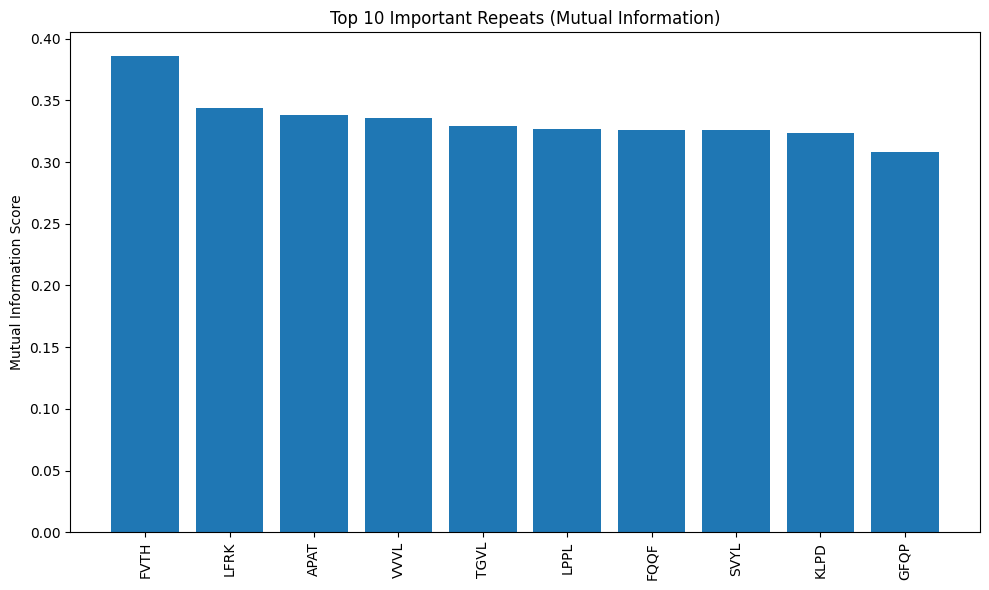

(MultinomialNB(),
 LabelEncoder(),
 ['LLTLL',
  'ARRA',
  'LLTR',
  'VGVI',
  'VYSYV',
  'TVTVT',
  'VPRPV',
  'VAST',
  'LLSLL',
  'LSVS',
  'LFSF',
  'SRMGMRS',
  'LVDT',
  'IGPGI',
  'FVHR',
  'SGKGS',
  'VLDRV',
  'VGSGSGV',
  'RSSSR',
  'TLVGVLT',
  'YVDVY',
  'VDFDV',
  'KFGL',
  'IYYI',
  'IKVL',
  'VPVI',
  'DEIV',
  'ADDA',
  'GSSD',
  'TSTST',
  'ELPLE',
  'VLGLV',
  'YTPTY',
  'QRALL',
  'TATAT',
  'KSQSK',
  'IHHI',
  'DIPF',
  'GKIV',
  'ADPS',
  'FAIAF',
  'SGDA',
  'AMQMA',
  'DSVSD',
  'PETI',
  'TAAAT',
  'YVVY',
  'SRRARRS',
  'LLTL',
  'VLLLLV',
  'DSSSD',
  'VEGF',
  'RGSF',
  'CCGCC',
  'AKVEA',
  'SSYSS',
  'SFVT',
  'TQSL',
  'SGIC',
  'FGSSGF',
  'SDLI',
  'TTTG',
  'DLQLD',
  'YQQY',
  'GLLS',
  'QLEQ',
  'EDDE',
  'EYYE',
  'LALAL',
  'SVVE',
  'VLILV',
  'AGDK',
  'PSIS',
  'ELELE',
  'PLLP',
  'VVDG',
  'SCFCS',
  'SLIP',
  'SIRIS',
  'TGIG',
  'FDSK',
  'IVLG',
  'VFFV',
  'TSRRST',
  'RTQTR',
  'FLSG',
  'KFAL',
  'QIIQ',
  'LVTVL',
  'RRHRR',
  'TGVL',
  

In [8]:
run_naive_bayes("../proba2NoDuplicates/indirect", 
                "../trainSetNoDuplicates", 
                "../testSetNoDuplicates", 
                "classification_report_NB_indirect_no_duplicates_2", top_features=10)

Number of unique repeats: 982


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

Classification report: 
              precision    recall  f1-score   support

   HCoV-229E       1.00      1.00      1.00        94
   HCoV-HKU1       1.00      1.00      1.00        56
   HCoV-NL63       1.00      1.00      1.00       103
   HCoV-OC43       1.00      0.98      0.99       196
         IBV       1.00      0.99      1.00      2097
    MERS-CoV       1.00      0.97      0.99       138
    SARS-CoV       0.00      0.00      0.00         2
   SARS-CoV2       1.00      1.00      1.00       661
     bat-CoV       0.86      1.00      0.92        12
  bovine-CoV       0.97      1.00      0.98       245
  canine-CoV       0.90      0.88      0.89       143
 dolphin-CoV       0.22      1.00      0.36         2
  equine-CoV       0.67      0.86      0.75         7
  feline-CoV       0.97      0.96      0.97       389
  ferret-CoV       0.71      0.56      0.62         9
hedgehog-CoV       0.62      1.00      0.77         5
 porcine-CoV       0.98      1.00      0.99        99
  r

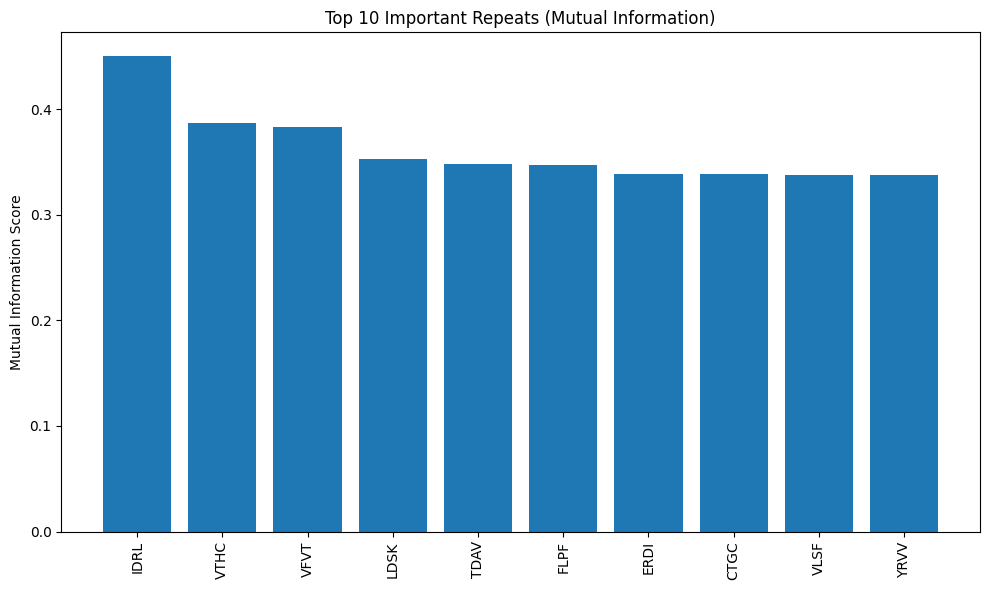

(MultinomialNB(),
 LabelEncoder(),
 ['GIGV',
  'IDTG',
  'RSRRS',
  'LPTS',
  'SEIY',
  'LVIG',
  'SISL',
  'YSIY',
  'DGLR',
  'LDSK',
  'VGVI',
  'IRVS',
  'IGVI',
  'VTYT',
  'VGTY',
  'DSDS',
  'AVDC',
  'CVRS',
  'VYRR',
  'STKP',
  'FGSL',
  'TGRL',
  'LTQH',
  'CSFG',
  'SLLM',
  'LEAQ',
  'LSVS',
  'YAYV',
  'TAYE',
  'GFIT',
  'TPEL',
  'PTVT',
  'FGIT',
  'TAEV',
  'TIIG',
  'LLGS',
  'SGYT',
  'ISTY',
  'SAAG',
  'SHSV',
  'ELYE',
  'VDGG',
  'LASS',
  'YTSS',
  'SSFG',
  'PFSVI',
  'FVED',
  'GELSK',
  'VTAS',
  'LRCR',
  'PVAS',
  'ILDQ',
  'SQTS',
  'TVDD',
  'PDGF',
  'GSGY',
  'LLAF',
  'GSLF',
  'IDRL',
  'RRRS',
  'VDGV',
  'AIVT',
  'SQQL',
  'RRRR',
  'SAIE',
  'SAIL',
  'VTKV',
  'LQSG',
  'GSYH',
  'GGVI',
  'IKVL',
  'AGAA',
  'SAIVT',
  'ELEE',
  'VYDG',
  'SAEL',
  'PIIT',
  'CVTT',
  'LQQV',
  'SGII',
  'VLYQ',
  'RSTS',
  'SISD',
  'ETYV',
  'FKTG',
  'VDTF',
  'VTPL',
  'ECGL',
  'FDFK',
  'GVTM',
  'QYRP',
  'TKLLS',
  'LGGY',
  'AIVP',
  'TVSD',
  'SVKS',


In [9]:
run_naive_bayes("../proba2NoDuplicates/direct", 
                "../trainSetNoDuplicates", 
                "../testSetNoDuplicates", 
                "classification_report_NB_direct_no_duplicates_2", top_features=10)

Number of unique repeats: 6993
Classification report: 
              precision    recall  f1-score   support

   HCoV-229E       0.97      0.97      0.97       153
   HCoV-HKU1       1.00      1.00      1.00       100
   HCoV-NL63       1.00      1.00      1.00       213
   HCoV-OC43       1.00      0.99      0.99       366
         IBV       1.00      0.98      0.99      3149
    MERS-CoV       1.00      0.99      0.99       395
    SARS-CoV       0.38      1.00      0.55         3
   SARS-CoV2       1.00      1.00      1.00      2133
     bat-CoV       0.94      1.00      0.97        15
  bovine-CoV       0.99      1.00      0.99       375
  canine-CoV       0.90      0.91      0.90       217
 dolphin-CoV       0.12      1.00      0.21         3
  equine-CoV       0.86      0.75      0.80         8
  feline-CoV       0.97      0.92      0.95       536
  ferret-CoV       0.38      1.00      0.55        13
hedgehog-CoV       0.22      1.00      0.36         6
 porcine-CoV       1.00   

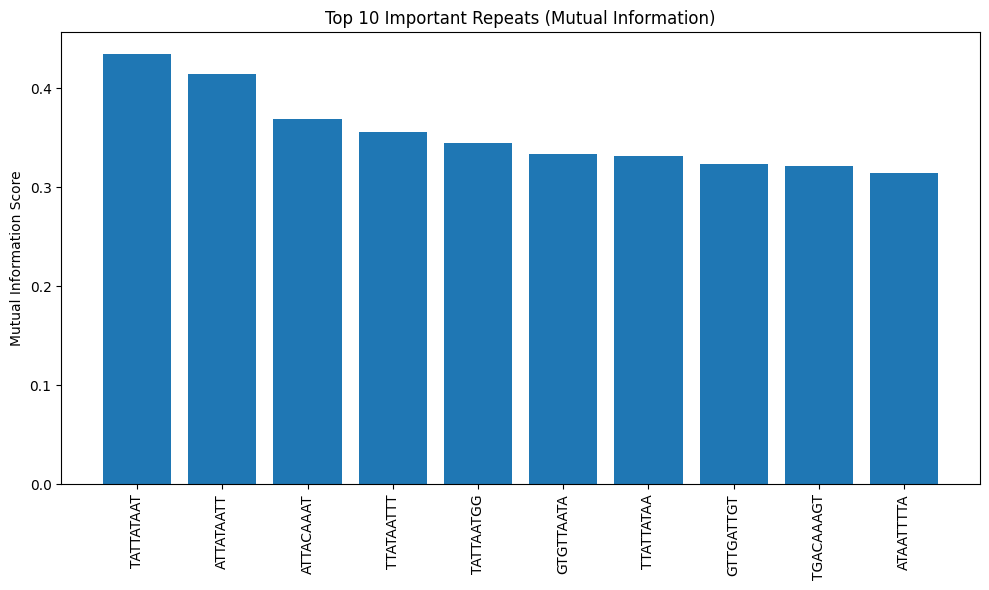

(MultinomialNB(),
 LabelEncoder(),
 ['TATAATTTAA',
  'TACTTCAAC',
  'AGAAAATCA',
  'TTTTCAAATT',
  'AGTACTACAAC',
  'GCAAGGTGGT',
  'ATATGGATTT',
  'CACAGTTACTGTGT',
  'TATATCGTA',
  'CAGTAGATC',
  'ATTATTACC',
  'GTAGTTAAT',
  'TACAATTGG',
  'TTTGTTGTG',
  'AACATGTGG',
  'TGTTATAATT',
  'TCTACCGTTA',
  'TACTACATA',
  'AATCAATTC',
  'ATGATTGCAC',
  'TAATACCTCG',
  'TCAAACTTT',
  'CACTTTTCAC',
  'GAATGACGA',
  'AATTTAGTGT',
  'ATAAAACTA',
  'CCACAAAAACAA',
  'ATGTTAATG',
  'AATCACCACT',
  'TCAGCATCT',
  'CTAAAAGTT',
  'TACCATAAT',
  'TACTATACT',
  'TACTATATC',
  'AAATCTTAAA',
  'AATCATTTT',
  'TGGTGAAGTC',
  'TCACGTCCG',
  'TTTAATACC',
  'TACTCAATG',
  'CAAATGTTC',
  'ACAGTAGTT',
  'TTTAAATTTA',
  'AATAGTGTTA',
  'TTTAACACCT',
  'ATAATAATT',
  'CTTACTTTGT',
  'ATATGGTAAC',
  'TGCAACAATT',
  'ACTTTACTA',
  'CTATACCAAA',
  'CAAACCATT',
  'ACTTCACTGT',
  'GTAGTGATGT',
  'ATGCTCTTAA',
  'TACATTTTA',
  'TTTGAGTTT',
  'TACAAAACTA',
  'TGTTAAAAT',
  'AAAGTAATT',
  'ATAAGGTTT',
  'AACAACACC',
 

In [2]:
run_naive_bayes("../proba3/DC", 
                "../trainSetNucl", 
                "../testSetNucl", 
                "classification_report_NB_DC_2", top_features=10)

Number of unique repeats: 11921
Classification report: 
              precision    recall  f1-score   support

   HCoV-229E       1.00      0.97      0.98       153
   HCoV-HKU1       1.00      1.00      1.00       100
   HCoV-NL63       1.00      1.00      1.00       213
   HCoV-OC43       1.00      0.99      0.99       366
         IBV       1.00      0.97      0.98      3149
    MERS-CoV       1.00      0.99      0.99       395
    SARS-CoV       0.14      1.00      0.25         3
   SARS-CoV2       1.00      1.00      1.00      2133
     bat-CoV       1.00      1.00      1.00        15
  bovine-CoV       0.99      1.00      0.99       375
  canine-CoV       0.90      0.87      0.88       217
 dolphin-CoV       0.05      1.00      0.10         3
  equine-CoV       1.00      0.75      0.86         8
  feline-CoV       0.96      0.96      0.96       536
  ferret-CoV       0.48      1.00      0.65        13
hedgehog-CoV       0.35      1.00      0.52         6
 porcine-CoV       1.00  

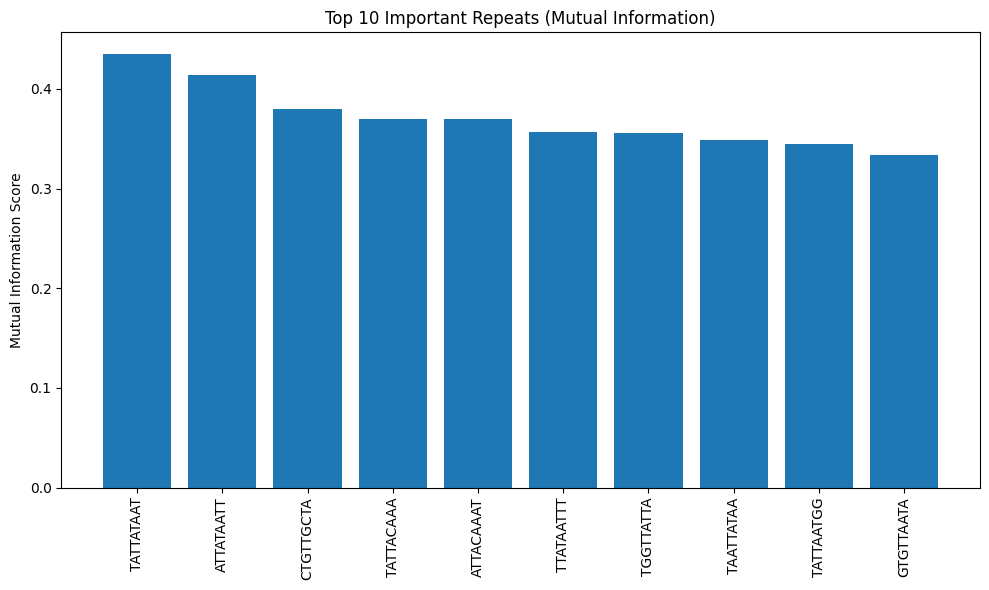

(MultinomialNB(),
 LabelEncoder(),
 ['TATAATTTAA',
  'GTTCAAATTA',
  'TGTGGTAATGG',
  'GCCAGACTT',
  'TGTAAAACT',
  'CAGATGCTG',
  'CAGGAAGGTT',
  'TATTTCTTTTA',
  'AATATGGTC',
  'ATCTTTTAT',
  'ATTTTTTCTA',
  'TTTGTATAA',
  'CCTTGTTATT',
  'TCACAGATG',
  'TATGGCATTG',
  'CGGCTGTTAT',
  'TCGTCTCAT',
  'CTTTTGCCA',
  'CTGCTAGTG',
  'AATATTAGT',
  'ATGTGGCACT',
  'TATAAAGTTA',
  'ATTAGCAAA',
  'CTGATATTA',
  'TACAACAGG',
  'CAGATGTAGCTG',
  'TCACTTCACGT',
  'ATTTTTAATCA',
  'CATATATGG',
  'TTTGTATTTT',
  'TACAATTGG',
  'CCGTTACTG',
  'TATAGAAACAT',
  'TAGTAGTATTACTTT',
  'GTTATTACA',
  'ACAATCTGA',
  'TGTTTGTAA',
  'CCATTAGTAGTT',
  'ACTTCTGGT',
  'TATAGTGGTC',
  'ATGATTGCAC',
  'TAAAAGTGATT',
  'TTCACTTTC',
  'TCTATTGCT',
  'GCCCGCTAA',
  'TAACATGTT',
  'AATCTAAGC',
  'CAACCTATT',
  'AAATTATTTA',
  'TTATGCAGA',
  'TAAGTGGTGT',
  'CAGAGACTAT',
  'TGCTCGTTC',
  'TTTCACTGT',
  'TGCAGGGCA',
  'ATGTTAATG',
  'CCAACAATTT',
  'TACACTTCT',
  'GTGGTACAGGG',
  'AATCTGTTT',
  'AGTTTAATAA',
  'TGGT

In [3]:
run_naive_bayes("../proba3/DN", 
                "../trainSetNucl", 
                "../testSetNucl", 
                "classification_report_NB_DN_2", top_features=10)

Number of unique repeats: 9112
Classification report: 
              precision    recall  f1-score   support

   HCoV-229E       1.00      0.97      0.98       153
   HCoV-HKU1       1.00      1.00      1.00       100
   HCoV-NL63       1.00      1.00      1.00       213
   HCoV-OC43       1.00      0.99      0.99       366
         IBV       1.00      0.98      0.99      3149
    MERS-CoV       1.00      0.99      0.99       395
    SARS-CoV       0.43      1.00      0.60         3
   SARS-CoV2       1.00      1.00      1.00      2133
     bat-CoV       1.00      1.00      1.00        15
  bovine-CoV       0.99      1.00      0.99       375
  canine-CoV       0.90      0.96      0.93       217
 dolphin-CoV       0.23      1.00      0.38         3
  equine-CoV       1.00      0.75      0.86         8
  feline-CoV       0.99      0.96      0.97       536
  ferret-CoV       0.43      1.00      0.60        13
hedgehog-CoV       0.25      1.00      0.40         6
 porcine-CoV       1.00   

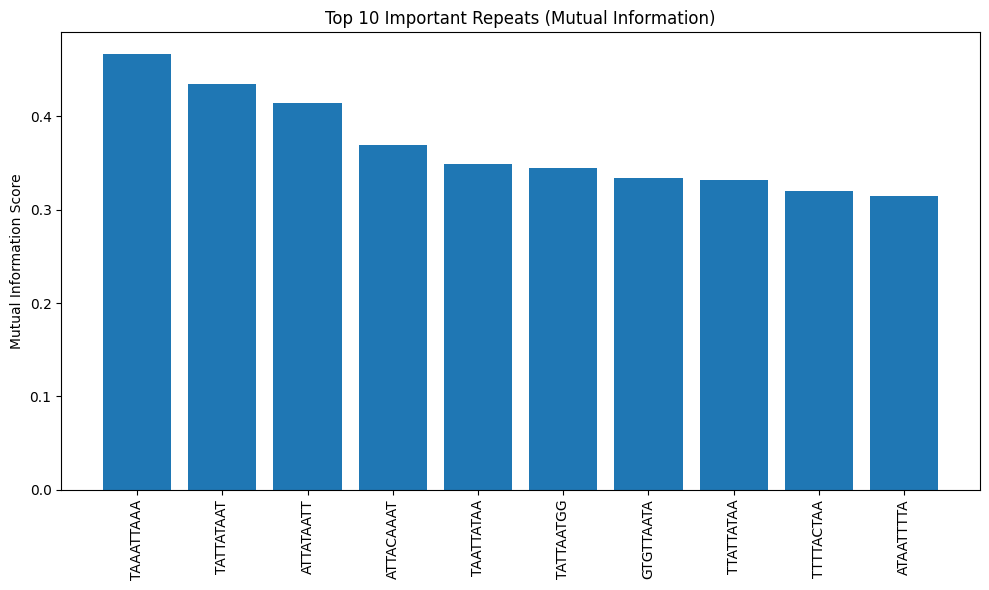

(MultinomialNB(),
 LabelEncoder(),
 ['TAGTAGTGA',
  'AAGTCTCAAT',
  'TTCTATTCA',
  'ATGTAGTAT',
  'AAATATATTT',
  'AATATGGTC',
  'CATTACCACA',
  'GATTGCAAA',
  'CTGTGCCTT',
  'TTTTCAAATT',
  'TGTTAGTAAT',
  'TACTGCTAATTT',
  'CTCAACCTCTT',
  'ATTTTAACA',
  'CACCACTTT',
  'TTATACCACC',
  'ATTATATATA',
  'TTAGCGTACGCTAA',
  'GTAGTTAAT',
  'TGTTAATGTCA',
  'GTTATTACA',
  'TGTTTGTAA',
  'TTAGTAACAT',
  'TAACATCTGT',
  'TTAGTAATAAAGC',
  'TGACGTTAG',
  'AGATTCAAGTC',
  'ACAAAAGTG',
  'CTGTGCAAA',
  'TTTTCAGCA',
  'CAGTTGTGT',
  'TATTCAATATGT',
  'TGTAACTAA',
  'ATTTAATAT',
  'GCTGTTTTG',
  'TGCTAATTG',
  'GTTAACAAA',
  'TGTCGCGACA',
  'CAGCAAGGG',
  'GTTTGCAATG',
  'CAACCTATT',
  'GAAGATCTTC',
  'CAATAGTAA',
  'TAGCATAAATA',
  'TTATGGGAT',
  'CACTTAATG',
  'TACACTTCT',
  'TGTTTGTTA',
  'AACTACCAA',
  'ACCTGATGA',
  'AATCTGTTT',
  'TCCTTGACA',
  'AGTTATTTA',
  'ATGTTATTA',
  'TTTCTAGTG',
  'AATATTAAG',
  'ATTAGTTAT',
  'CTCAGACAT',
  'ACATCAGTTT',
  'ATGTTGCCG',
  'CTTAATAAG',
  'CTAGCTTGT',

In [4]:
run_naive_bayes("../proba3/IC", 
                "../trainSetNucl", 
                "../testSetNucl", 
                "classification_report_NB_IC_2", top_features=10)

Number of unique repeats: 9258
Classification report: 
              precision    recall  f1-score   support

   HCoV-229E       1.00      0.97      0.98       153
   HCoV-HKU1       1.00      1.00      1.00       100
   HCoV-NL63       1.00      1.00      1.00       213
   HCoV-OC43       1.00      0.99      0.99       366
         IBV       1.00      0.98      0.99      3149
    MERS-CoV       1.00      0.99      0.99       395
    SARS-CoV       0.60      1.00      0.75         3
   SARS-CoV2       1.00      1.00      1.00      2133
     bat-CoV       1.00      1.00      1.00        15
  bovine-CoV       0.99      1.00      0.99       375
  canine-CoV       0.91      0.93      0.92       217
 dolphin-CoV       0.18      1.00      0.30         3
  equine-CoV       1.00      0.75      0.86         8
  feline-CoV       0.97      0.96      0.97       536
  ferret-CoV       0.45      1.00      0.62        13
hedgehog-CoV       0.18      1.00      0.31         6
 porcine-CoV       1.00   

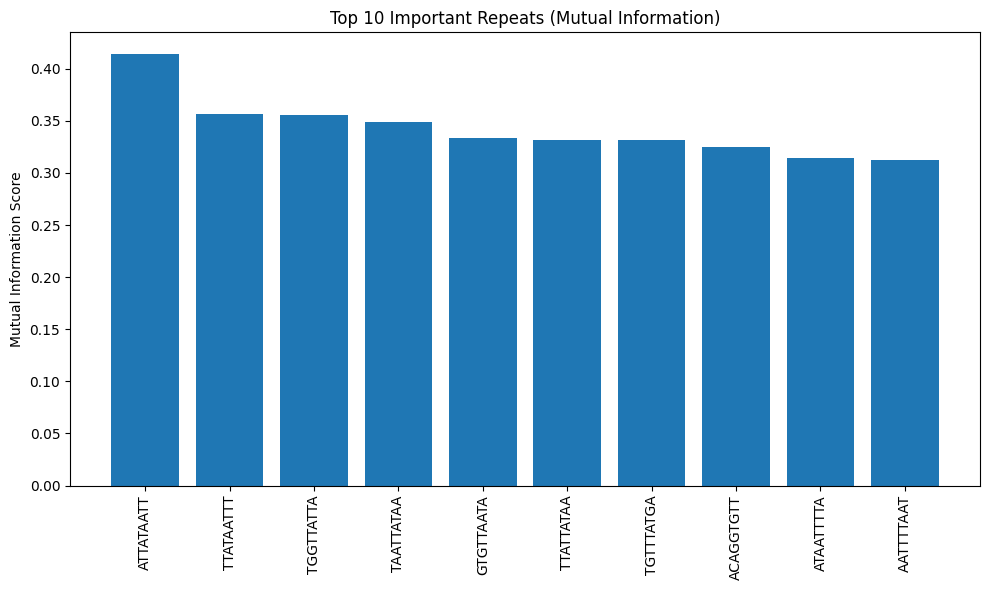

(MultinomialNB(),
 LabelEncoder(),
 ['TTATGGGTATT',
  'TAGTTATCAT',
  'GTAAAAAAT',
  'AAATCATCT',
  'ACTCTCTCT',
  'TTTGAGGAGTTT',
  'ATTACTCATTA',
  'TTTGTATAA',
  'TGACCAGTTGT',
  'AATATTAGT',
  'AATAATTCCAA',
  'TGAGACTAC',
  'ATTTTAACA',
  'TACAACAGG',
  'GAACACGAC',
  'TGGAAAAGA',
  'TTCTTGTTC',
  'TTTGTTGTG',
  'AAGCATTGA',
  'GTGATTCGA',
  'AAGAACTTC',
  'CTAATCTGG',
  'ACTCAAATA',
  'AGCACATTAT',
  'TGTGGTGAT',
  'CACTTTTCAC',
  'TTCTTCTCGT',
  'TTGGTAATCA',
  'CAGAATAATT',
  'GTTGTGTCAT',
  'GTTTAATTTG',
  'TTGTGGACC',
  'AATCAACGT',
  'TTTGGATAAT',
  'ACATTTTGG',
  'ACATTGACT',
  'TGTGAATGTA',
  'TATTTGTAG',
  'CTAATTTCT',
  'ACAATACAGG',
  'TAGTGTTTTT',
  'AGTTATTTA',
  'AACTATCAA',
  'GTGGATTGA',
  'ATCTTCTAA',
  'GTGACCAGTG',
  'ACTATTTCT',
  'GTAGGTGGTG',
  'TTTCTAGTG',
  'CCTGTTTTTA',
  'GTAGGTGTT',
  'GGTTATTGG',
  'GACGTTTTGCAG',
  'TCGATAGCT',
  'CTGATCACT',
  'TATCGTTCA',
  'TTGATTGTAT',
  'CACTTGGAAAAGCT',
  'ATCTTCAGGT',
  'CTGGAATAG',
  'TAGAAGTTG',
  'AGAAATTGCT'

In [5]:
run_naive_bayes("../proba3/IN", 
                "../trainSetNucl", 
                "../testSetNucl", 
                "classification_report_NB_IN_2", top_features=10)

Number of unique repeats: 4509
Classification report: 
              precision    recall  f1-score   support

   HCoV-229E       1.00      0.97      0.99       120
   HCoV-HKU1       1.00      1.00      1.00        70
   HCoV-NL63       1.00      1.00      1.00       154
   HCoV-OC43       1.00      0.98      0.99       252
         IBV       0.78      0.97      0.86      2267
    MERS-CoV       1.00      0.98      0.99       198
    SARS-CoV       0.00      0.00      0.00         2
   SARS-CoV2       0.00      0.00      0.00       624
     bat-CoV       0.81      1.00      0.90        13
  bovine-CoV       0.97      1.00      0.98       276
  canine-CoV       0.92      0.89      0.90       162
 dolphin-CoV       0.33      1.00      0.50         2
  equine-CoV       0.86      0.86      0.86         7
  feline-CoV       0.97      0.94      0.95       444
  ferret-CoV       0.85      1.00      0.92        11
hedgehog-CoV       0.31      1.00      0.48         5
 porcine-CoV       1.00   

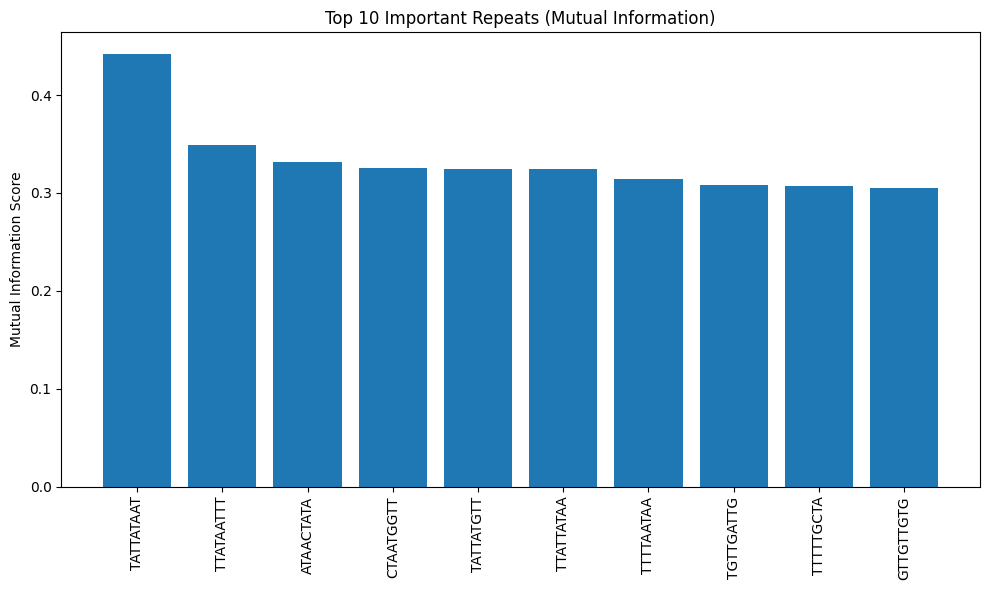

(MultinomialNB(),
 LabelEncoder(),
 ['AACTTTGTA',
  'CTCCTGAAT',
  'AGATGCTGTC',
  'TGATGATAGT',
  'AAGCATTAG',
  'GACAATTTTA',
  'ATTAACGATT',
  'AAAATTTAT',
  'ACAAACACG',
  'TTACATGTC',
  'TAATAATTA',
  'AATAATATGT',
  'AGAGGTGTTTATTA',
  'ACAACAACG',
  'AGGTGATGT',
  'CCCAAACTA',
  'ACTTTACTT',
  'AATAAAAAT',
  'TGTGAATAA',
  'AGACATAAT',
  'TACATATAC',
  'TGACAAGTTCT',
  'ACACTGGTC',
  'TATTACCTAA',
  'GGTGGAGTT',
  'AAACAATGT',
  'GGAATCGAA',
  'TCTGTTACT',
  'TTGGTTATT',
  'ACACAAGAT',
  'TGTACCACA',
  'ACTGTTATC',
  'CGAATTAAT',
  'GTTAGAGGA',
  'TTGTTAATTC',
  'TTACACCATTC',
  'CCAAAAGAA',
  'AAATTTTTG',
  'ATTAATAAA',
  'TAACAAAAT',
  'AATTGATAC',
  'CACACCATT',
  'TTTTTAATA',
  'ATAATAATGTT',
  'ACAGTTAGT',
  'TTCAACTAG',
  'TAAGAATGA',
  'GAGCTTTGT',
  'CTGTGGTGC',
  'ATTACTTAG',
  'TATTGCCAA',
  'GATGTATTG',
  'ACGTTGTTT',
  'TTGTTATAAAA',
  'CCTTTTACTA',
  'TTTGTGAAT',
  'CCAGTCCTT',
  'CGACACTAA',
  'CACAGTAGAT',
  'AACACTACA',
  'TACTATTCTA',
  'TGGTTCTTT',
  'ACATTATTA

In [4]:
run_naive_bayes("../proba2NoDuplicatesNucl/DC", 
                "../trainSetNoDuplicatesNucl", 
                "../testSetNoDuplicatesNucl", 
                "classification_report_NB_DC_no_duplicates_2", top_features=10)

Number of unique repeats: 8047
Classification report: 
              precision    recall  f1-score   support

   HCoV-229E       1.00      0.97      0.99       120
   HCoV-HKU1       1.00      1.00      1.00        70
   HCoV-NL63       1.00      1.00      1.00       154
   HCoV-OC43       1.00      0.98      0.99       252
         IBV       0.78      0.96      0.86      2267
    MERS-CoV       1.00      0.98      0.99       198
    SARS-CoV       0.00      0.00      0.00         2
   SARS-CoV2       0.00      0.00      0.00       624
     bat-CoV       0.87      1.00      0.93        13
  bovine-CoV       0.98      1.00      0.99       276
  canine-CoV       0.92      0.86      0.89       162
 dolphin-CoV       0.40      1.00      0.57         2
  equine-CoV       1.00      0.86      0.92         7
  feline-CoV       0.96      0.97      0.96       444
  ferret-CoV       0.69      1.00      0.81        11
hedgehog-CoV       0.56      1.00      0.71         5
 porcine-CoV       1.00   

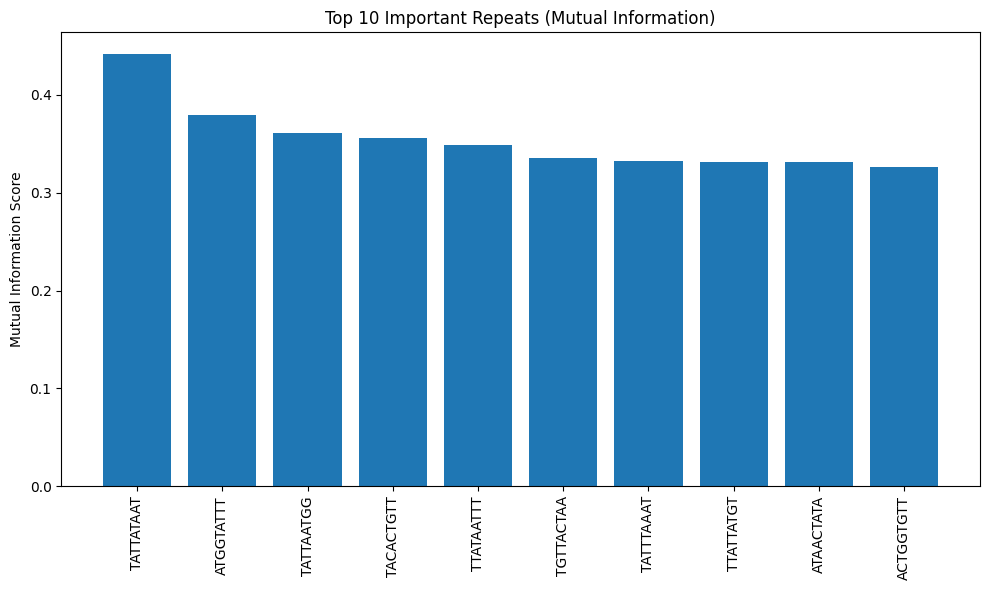

(MultinomialNB(),
 LabelEncoder(),
 ['AATGATTAC',
  'TGATGAATT',
  'TTGTGGTAA',
  'ACATGGAGA',
  'CAGACAATT',
  'AATACTTGCA',
  'ATTTTAGCT',
  'AGAAAAATTT',
  'GTACTGCAC',
  'ACTAATGTAAGT',
  'AACTTTAGA',
  'AATTGGGAA',
  'ATGCTGTTG',
  'TTTTGAGTG',
  'TATACCTGA',
  'TAGAAACTA',
  'GTACTTGCC',
  'TACTGGTGAAAT',
  'CTCAATTGT',
  'GGTGTTGGC',
  'CTCAACTTA',
  'TGCTAGTAA',
  'TGCAGCTTC',
  'CAGTTTGTGG',
  'TATTTATAA',
  'ATTCTCACT',
  'CTGTGGTGC',
  'ACTTTTGATA',
  'CAACAAATT',
  'GTTAATGAAA',
  'GTATTATAA',
  'TTCTGTTGTT',
  'TTGCCTCTC',
  'TGCAACTGT',
  'ATAGTTATA',
  'GTTCTATTAC',
  'TCATTGGTT',
  'GCTATTACAA',
  'TAATTACTG',
  'GGTTGTGGTAC',
  'TGTGGAAAT',
  'TACATACAAT',
  'CCAGAAAGC',
  'TAGAAGCAC',
  'AATGGCAAT',
  'TTAGTAATTTTAC',
  'AAATTACAGT',
  'CCACAGAAT',
  'AACTTTTAAT',
  'AATAGTGGT',
  'ATTTTTCTA',
  'ATCTACTTA',
  'CAATTTTGC',
  'TAATGAGCA',
  'GCCACTCAGA',
  'CTATTAAGT',
  'TTCCTCTTC',
  'ATTTTTGTT',
  'AGTAATTATACT',
  'GCAATTTTAGA',
  'AACTATAGA',
  'GCATAACTGA',
  'TG

In [6]:
run_naive_bayes("../proba2NoDuplicatesNucl/DN", 
                "../trainSetNoDuplicatesNucl", 
                "../testSetNoDuplicatesNucl", 
                "classification_report_NB_DN_no_duplicates_2", top_features=10)

Number of unique repeats: 6144
Classification report: 
              precision    recall  f1-score   support

   HCoV-229E       1.00      0.97      0.99       120
   HCoV-HKU1       1.00      1.00      1.00        70
   HCoV-NL63       1.00      1.00      1.00       154
   HCoV-OC43       1.00      0.98      0.99       252
         IBV       0.78      0.98      0.87      2267
    MERS-CoV       1.00      0.98      0.99       198
    SARS-CoV       0.00      0.00      0.00         2
   SARS-CoV2       0.00      0.00      0.00       624
     bat-CoV       0.87      1.00      0.93        13
  bovine-CoV       0.98      1.00      0.99       276
  canine-CoV       0.92      0.88      0.90       162
 dolphin-CoV       0.67      1.00      0.80         2
  equine-CoV       1.00      0.86      0.92         7
  feline-CoV       0.96      0.97      0.97       444
  ferret-CoV       0.58      1.00      0.73        11
hedgehog-CoV       0.71      1.00      0.83         5
 porcine-CoV       1.00   

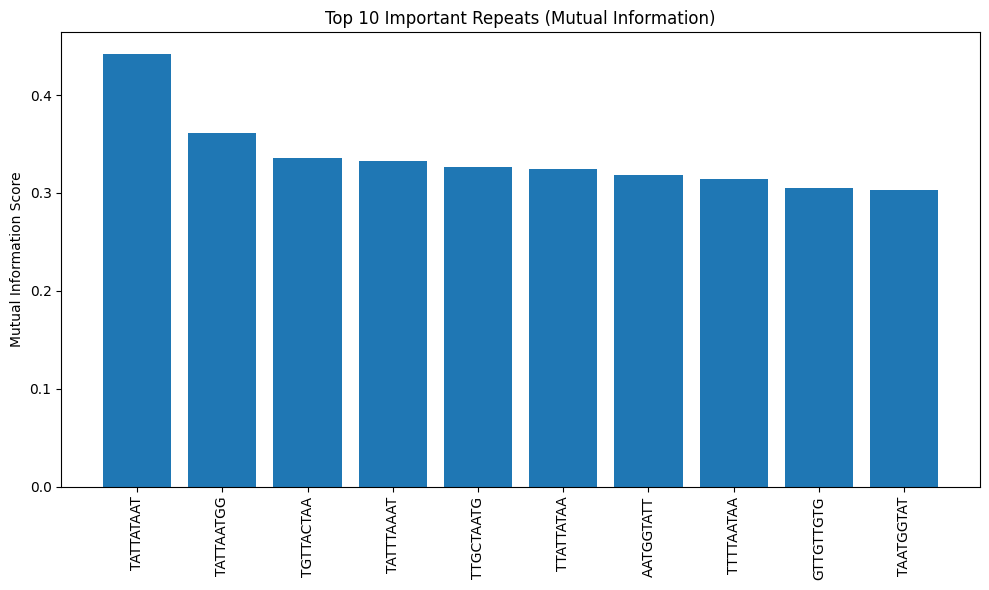

(MultinomialNB(),
 LabelEncoder(),
 ['TGGGTTCCAT',
  'AGGTGGTGTTAA',
  'CTAGCACGA',
  'CTTGTCAATAT',
  'ACAAACTGC',
  'CAGTTGTATT',
  'ACAACAACG',
  'ATGCCAAAG',
  'TTAAGCCTG',
  'TTTTGAGTG',
  'TGCAAATGG',
  'TGCCAGTAT',
  'TTGGTTTTTATT',
  'CTTATTAATAAG',
  'TTAGAATAT',
  'ACCAACAACA',
  'TCATGGCAC',
  'TATTTATAA',
  'CAAGGTCCT',
  'GTATTTACA',
  'GCTGGTTAC',
  'GGTGCAGTT',
  'GCAGTTTCA',
  'AAATCAGGGA',
  'AAGAAAAGT',
  'AAGCTTATT',
  'TGGTAGAAC',
  'AATGATGTC',
  'AGCATCATT',
  'TGTGTCAGT',
  'CATGGCAAA',
  'AAGTATGCC',
  'CCTGGCCAGG',
  'GTAGTAATG',
  'ACTGTAACTT',
  'GTGTTAGCA',
  'AATCACTAC',
  'TGATATATCA',
  'AACTATAGA',
  'TTACATTTT',
  'ATTACATAT',
  'ATGTCACTA',
  'ATAAAAAAT',
  'TAGCACCAAG',
  'ACCATTTTG',
  'ATTGACAGCT',
  'TAACCAGTG',
  'TACTATTAAGT',
  'AGATGTAAG',
  'GTCGTGACA',
  'ACAAATAAA',
  'TGTCTGCTAG',
  'AATCCTTGT',
  'TCTTTTTAATA',
  'ACCAGACCA',
  'ACAAAACTAC',
  'CCTGAATCT',
  'TGTAGTTTCAAC',
  'CTGCCTGTAA',
  'ACACATATGCATATGTGT',
  'TCAACCATT',
  'CGTTTACA

In [7]:
run_naive_bayes("../proba2NoDuplicatesNucl/IC", 
                "../trainSetNoDuplicatesNucl", 
                "../testSetNoDuplicatesNucl", 
                "classification_report_NB_IC_no_duplicates_2", top_features=10)

Number of unique repeats: 6346
Classification report: 
              precision    recall  f1-score   support

   HCoV-229E       1.00      0.97      0.99       120
   HCoV-HKU1       1.00      1.00      1.00        70
   HCoV-NL63       1.00      1.00      1.00       154
   HCoV-OC43       1.00      0.98      0.99       252
         IBV       0.78      0.97      0.86      2267
    MERS-CoV       1.00      0.98      0.99       198
    SARS-CoV       0.00      0.00      0.00         2
   SARS-CoV2       0.00      0.00      0.00       624
     bat-CoV       0.81      1.00      0.90        13
  bovine-CoV       0.98      1.00      0.99       276
  canine-CoV       0.91      0.86      0.89       162
 dolphin-CoV       0.33      1.00      0.50         2
  equine-CoV       1.00      0.86      0.92         7
  feline-CoV       0.96      0.96      0.96       444
  ferret-CoV       0.65      1.00      0.79        11
hedgehog-CoV       0.23      1.00      0.37         5
 porcine-CoV       1.00   

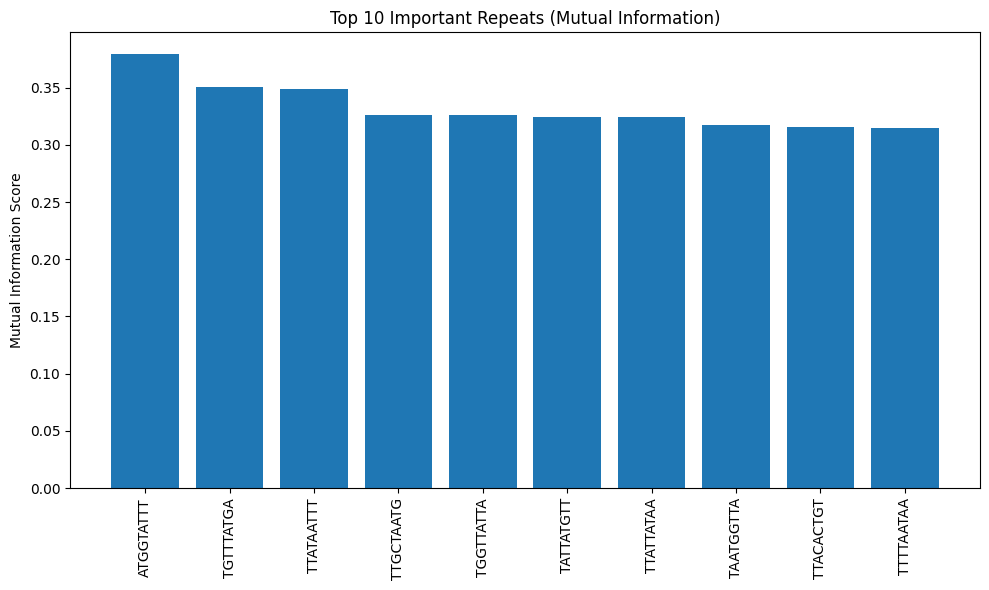

(MultinomialNB(),
 LabelEncoder(),
 ['GGTGTAGGA',
  'TTGATGCTT',
  'GAAGTTATTT',
  'ACACCTCTAA',
  'GACTATTGT',
  'AACTTAACA',
  'TCTTCCTAAT',
  'GGATTTAGG',
  'GTTTGGTATA',
  'CCCAGTTTA',
  'ATGTCACTC',
  'GAACATATT',
  'TTATAGTAATC',
  'TTAATCATCC',
  'ATTCTGGTT',
  'TATTTATAA',
  'ATTTGGTAGT',
  'TATAATGTT',
  'ATTTTGACTA',
  'TTCTGTTGTT',
  'ACATAGAGT',
  'TCTCATTGTT',
  'TCTACCTAAG',
  'CAAAACATT',
  'ATTTTGATTTA',
  'TCGTAATAA',
  'ATTTTTTCT',
  'ATTATTAAC',
  'AATCATGAT',
  'TACATACAAT',
  'TGAAAATAA',
  'ATAAGTCTA',
  'TTATTAATTATT',
  'AACTTTTAAT',
  'GTTTTAGTA',
  'GTTTTAGTAA',
  'TGTAAATGT',
  'ACGTTAAAAG',
  'TGTTGAGCA',
  'ACTCCAAAT',
  'TTGATTTTAGTT',
  'GATGTTTCT',
  'TATTACTGA',
  'AACTAATTA',
  'ACCAGAAAG',
  'CTTGATGTT',
  'GTTTGTTGTGTA',
  'TTGACTTCA',
  'ACCAGACCA',
  'TCGGCGGCT',
  'TGTCACATT',
  'TCGTAATGT',
  'AGAGCAACA',
  'TGATTTCACA',
  'GTCACACACTG',
  'TGGTGGTTTT',
  'AAGGAACTGT',
  'TAGACTACCA',
  'ATCAAGGTGT',
  'TCTTGCTAT',
  'TCTCGCTCT',
  'GAATCGTAT',
 

In [8]:
run_naive_bayes("../proba2NoDuplicatesNucl/IN", 
                "../trainSetNoDuplicatesNucl", 
                "../testSetNoDuplicatesNucl", 
                "classification_report_NB_IN_no_duplicates_2", top_features=10)

In [2]:
import os
from Bio import SeqIO
from collections import Counter
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

def run_naive_bayes(repeats_folder, train_folder, test_folder, output_file, top_features=10):
    # -----------------------------
    # 1️⃣ Load known repeats
    repeats = []
    for file in os.listdir(repeats_folder):
        if file.startswith("."):
            continue
        with open(os.path.join(repeats_folder, file), "r") as f:
            for line in f:
                parts = line.strip().split(",")
                if len(parts) >= 2:
                    repeats.append(parts[1])
    known_repeats = list(set(r for r in repeats if "X" not in r))
    known_repeats = list(set(r for r in known_repeats if "N" not in r))
    print(f"Number of unique repeats: {len(known_repeats)}")

    # -----------------------------
    # 2️⃣ Load training data
    sequencesTrain, labelTrain = [], []
    for file in os.listdir(train_folder):
        if file.startswith("."):
            continue
        filepath = os.path.join(train_folder, file)
        for record in SeqIO.parse(filepath, "fasta"):
            sequencesTrain.append(str(record.seq))
            labelTrain.append(file.replace(".fasta", ""))

    # -----------------------------
    # 3️⃣ Load test data
    sequencesTest, labelTest = [], []
    for file in os.listdir(test_folder):
        if file.startswith("."):
            continue
        filepath = os.path.join(test_folder, file)
        for record in SeqIO.parse(filepath, "fasta"):
            sequencesTest.append(str(record.seq))
            labelTest.append(file.replace(".fasta", ""))

    # -----------------------------
    # 4️⃣ Feature extraction
    def extract_repeat_counts(sequence, repeat_list):
        return [sequence.count(r) for r in repeat_list]

    X_train = [extract_repeat_counts(seq, known_repeats) for seq in sequencesTrain]
    X_test = [extract_repeat_counts(seq, known_repeats) for seq in sequencesTest]

    # -----------------------------
    # 5️⃣ Encode labels
    encoder = LabelEncoder()
    y_train_enc = encoder.fit_transform(labelTrain)
    y_test_enc = encoder.transform(labelTest)

    # -----------------------------
    # 6️⃣ Train Naive Bayes
    nb = MultinomialNB()
    nb.fit(X_train, y_train_enc)

    # -----------------------------
    # 7️⃣ Predict & Evaluate
    y_pred_enc = nb.predict(X_test)
    y_pred = encoder.inverse_transform(y_pred_enc)
    y_true = encoder.inverse_transform(y_test_enc)

    y_pred_enc_train = nb.predict(X_train)
    y_pred_train = encoder.inverse_transform(y_pred_enc_train)
    y_true_train = encoder.inverse_transform(y_train_enc)

    report = classification_report(y_true, y_pred)
    acc_test = accuracy_score(y_true, y_pred)
    acc_train = accuracy_score(y_true_train, y_pred_train)

    print("Classification report: ")
    print(report)
    print("Accuracy score test: " + str(acc_test))
    print("Accuracy score train: " + str(acc_train))

    with open(output_file, "w") as f:
        f.write(report)
        f.write("\nAccuracy score test: " + str(acc_test))
        f.write("\nAccuracy score train: " + str(acc_train))

    # -----------------------------
    # 8️⃣ Global Feature Importance via Mutual Information
    mi = mutual_info_classif(X_train, y_train_enc, discrete_features=True)
    top_indices = np.argsort(mi)[::-1][:top_features]

    # -----------------------------
    # 9️⃣ Plot feature importance
    plt.figure(figsize=(10, 6))
    plt.bar(range(top_features), mi[top_indices], align="center")
    plt.xticks(range(top_features), [known_repeats[i] for i in top_indices], rotation=90)
    plt.title(f"Top {top_features} Important Repeats (Mutual Information)")
    plt.ylabel("Mutual Information Score")
    plt.tight_layout()
    plt.show()

    return nb, encoder, known_repeats

Number of unique repeats: 2989


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

Classification report: 
              precision    recall  f1-score   support

   HCoV-229E       1.00      1.00      1.00       153
   HCoV-HKU1       1.00      1.00      1.00       100
   HCoV-NL63       1.00      1.00      1.00       213
   HCoV-OC43       0.99      0.99      0.99       366
         IBV       0.97      1.00      0.98      3149
    MERS-CoV       1.00      0.99      1.00       395
    SARS-CoV       0.00      0.00      0.00         3
   SARS-CoV2       1.00      0.99      1.00      2133
     bat-CoV       0.83      1.00      0.91        15
  bovine-CoV       0.98      1.00      0.99       375
  canine-CoV       0.95      0.88      0.91       217
 dolphin-CoV       1.00      1.00      1.00         3
  equine-CoV       1.00      0.88      0.93         8
  feline-CoV       0.95      0.83      0.89       536
  ferret-CoV       1.00      0.38      0.56        13
hedgehog-CoV       1.00      0.83      0.91         6
 porcine-CoV       1.00      1.00      1.00       132
  r

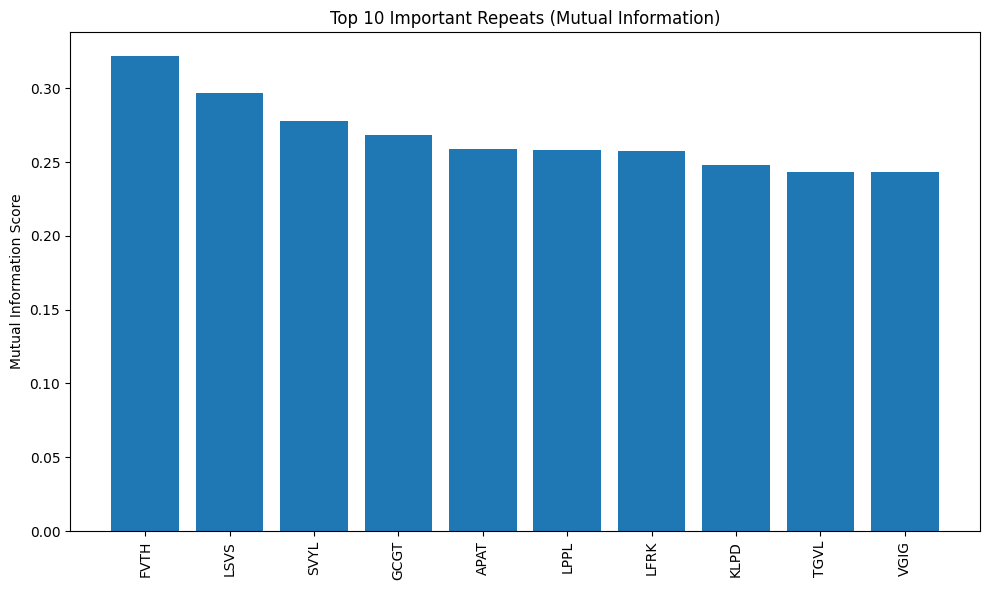

(MultinomialNB(),
 LabelEncoder(),
 ['IFSR',
  '"IASQ',
  '"LITGR',
  '"ITTI',
  'SLTLS',
  'LELQ',
  '"YSTS',
  '"TTLTT',
  '"ILCG',
  '"VLHLV',
  '"LIGL',
  'GQMY',
  'KTPPTK',
  '"RTQTR',
  '"VRLY',
  'YSKFKSY',
  '"YALV',
  '"PTATP',
  '"VDKY',
  '"SYQS',
  'LGKP',
  '"SYSV',
  'TQPL',
  '"FSGR',
  'ASIS',
  '"DVAD',
  'YSGQ',
  '"IKTS',
  '"CFGV',
  'YDDY',
  'LLALL',
  'YVQVY',
  '"CPCICPC',
  '"VIGIV',
  'SSFVS',
  'YLAGE',
  '"DVVD',
  '"FPID',
  '"YAYAY',
  'ISLT',
  'DVMVD',
  '"DMFMD',
  '"FQSF',
  'ITTI',
  'TGSG',
  'TARS',
  '"DDDD',
  '"VLVD',
  'QLRQ',
  'DDFDFDD',
  'SGVGS',
  'LPGY',
  'GCCGCCG',
  'LEEL',
  '"RLLR',
  '"DTCTD',
  'IDKF',
  '"RRPRR',
  'SRRVRRS',
  'LESEL',
  '"KDVS',
  'SLSVSLS',
  'LLPI',
  '"GSVL',
  '"GLVI',
  'LSSF',
  'VPEPV',
  'VLGD',
  '"STAST',
  'ATLLTA',
  '"YGGY',
  'RSTI',
  '"LVDV',
  '"LDVDL',
  '"STSTS',
  '"LVSSVL',
  '"TVSE',
  'YTIG',
  'QLEV',
  '"AQQA',
  'TEFQ',
  '"QLDLQ',
  'FPLV',
  'SVVL',
  '"QTSV',
  'QLEH',
  '"GMAMG',
  

In [3]:
run_naive_bayes("../proba2/indirect", 
                "../trainSet", 
                "../testSet", 
                "proba2ponovka_NB_indirect", top_features=10)

Number of unique repeats: 1979


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

Classification report: 
              precision    recall  f1-score   support

   HCoV-229E       1.00      1.00      1.00       153
   HCoV-HKU1       1.00      1.00      1.00       100
   HCoV-NL63       1.00      1.00      1.00       213
   HCoV-OC43       1.00      0.98      0.99       366
         IBV       1.00      1.00      1.00      3149
    MERS-CoV       1.00      1.00      1.00       395
    SARS-CoV       0.00      0.00      0.00         3
   SARS-CoV2       1.00      1.00      1.00      2133
     bat-CoV       0.83      1.00      0.91        15
  bovine-CoV       0.97      1.00      0.99       375
  canine-CoV       0.88      0.91      0.90       217
 dolphin-CoV       1.00      1.00      1.00         3
  equine-CoV       0.78      0.88      0.82         8
  feline-CoV       0.97      0.96      0.96       536
  ferret-CoV       1.00      0.46      0.63        13
hedgehog-CoV       0.86      1.00      0.92         6
 porcine-CoV       0.99      1.00      0.99       132
  r

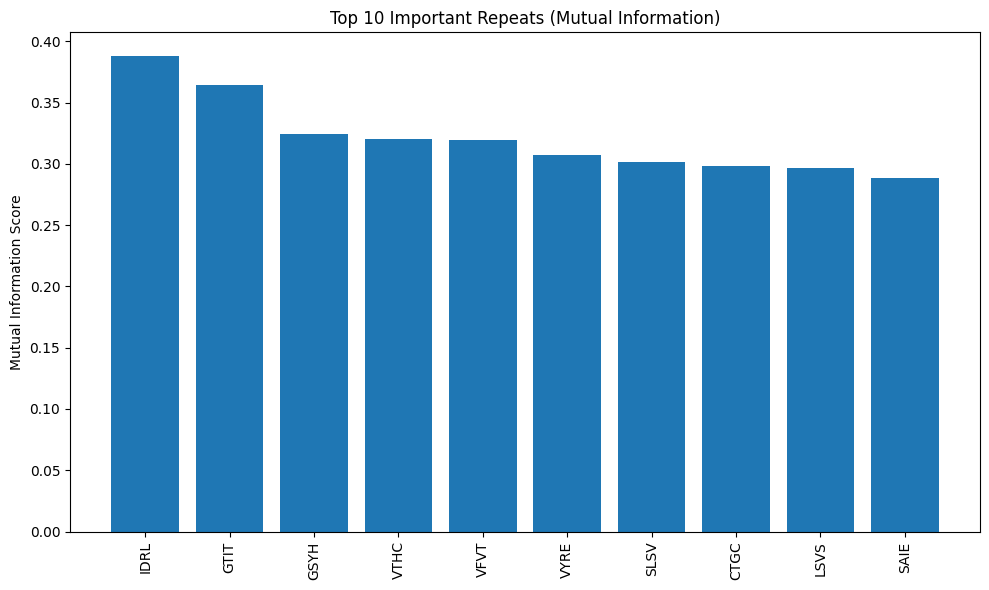

(MultinomialNB(),
 LabelEncoder(),
 ['"SQTL',
  '"LSIV',
  'SVYA',
  'TAGG',
  '"GVAD',
  '"LTQH',
  'VITY',
  'VKSQ',
  'QGVI',
  '"ITLA',
  'SGVG',
  '"FIRR',
  'TTSD',
  'YGVSGR',
  '"SSSR',
  '"LTGT',
  '"ITQS',
  '"LFTG',
  '"APVL',
  'SGFVV',
  'ASIS',
  '"TIIG',
  '"DVAD',
  'LSIV',
  'LEKV',
  '"SDGD',
  'AYTS',
  '"PLTG',
  'SLLLK',
  '"GTIT',
  'SLII',
  'LPTG',
  'VGSG',
  'FSYL',
  '"LPTS',
  'LTQH',
  '"LSLLT',
  '"TVGS',
  'VSIG',
  'SGLG',
  'TSAG',
  'TGQG',
  'YTSA',
  '"VYRE',
  'IGQG',
  '"QQGE',
  'TGSG',
  'PTGV',
  '"PSGL',
  '"CVDG',
  '"LALL',
  'VGTY',
  'CFST',
  '"LSVL',
  'TAEV',
  'QGFI',
  '"ARTR',
  'SVST',
  '"DGSL',
  'YGQF',
  '"CTLDPI',
  '"SSIT',
  '"WSVV',
  '"TTAY',
  '"VQVE',
  '"YERL',
  '"TVSE',
  '"SLLLK',
  'DIFV',
  '"GVYS',
  'SGYY',
  '"AYTS',
  '"SGFVV',
  'FATI',
  'TARD',
  '"QGEY',
  'SAVA',
  'IECK',
  'VYRR',
  '"GSLI',
  '"FCIKP',
  '"VSVA',
  'SASL',
  '"TPEL',
  '"GLDI',
  'YRVV',
  '"TILGG',
  'FLCTGC',
  '"SGECI',
  'QDVV',
  'RQ

In [4]:
run_naive_bayes("../proba2/direct", 
                "../trainSet", 
                "../testSet", 
                "proba2ponovka_NB_direct", top_features=10)